# Setup

In [1]:
import scvi
import scrnatools as rna
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import celltypist
import os
import shutil
import anndata as ad
import scanpy as sc

In [2]:
# Setup seeds
scvi.settings.seed = 0

Seed set to 0


In [3]:
# Setup figure params
plt.rcParams["pdf.use14corefonts"] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = "Arial"
sc.set_figure_params(dpi=80, dpi_save=300, facecolor="white", frameon=False)
sns.set_context("paper")
plt.rcParams["axes.grid"] = False
cmap = sns.color_palette("colorblind")
# Get the tab20 colormap
tab20_cmap = plt.get_cmap('tab20')

# Create a new colormap without the 7th and 8th colors
colors_to_exclude = [6, 7]  # 0-based index, so 6 and 7 represent the 7th and 8th colors
new_tab20 = [tab20_cmap(i) for i in range(tab20_cmap.N) if i not in colors_to_exclude]

## Set data paths

### demeter

In [4]:
rawDataPath = "/mnt/iacchus/joe/raw_data/"
processedDataPath = "/mnt/iacchus/joe/processed_data/"

# Import raw data

## Stromal

In [5]:
stromal = sc.read_10x_h5(
    f"{rawDataPath}/Thymus/Corey/cellranger_alignment/CS/filtered_feature_bc_matrix.h5",
)
stromal.var_names_make_unique()
stromal.layers["raw_counts"] = stromal.X.copy()

## Myeloid

In [6]:
myeloid = sc.read_10x_h5(
    f"{rawDataPath}/Thymus/Corey/cellranger_alignment/CM/filtered_feature_bc_matrix.h5",
)
myeloid.var_names_make_unique()
myeloid.layers["raw_counts"] = myeloid.X.copy()

# Preprocessing

In [7]:
def initial_filter(adata):
    # Get biomart gene annotations
    gene_info = sc.queries.biomart_annotations("mmusculus", ["external_gene_name", "gene_biotype"])
    gene_info.index = gene_info.external_gene_name
    gene_info = gene_info[gene_info.index.isin(adata.var_names)]
    gene_info = gene_info.drop_duplicates(subset="external_gene_name")
    adata = adata[:, adata.var_names.isin(gene_info.index)].copy()
    adata.var = adata.var.join(gene_info)
    # Drop transcripts with no gene name
    adata = adata[:, ~adata.var.external_gene_name.isna()].copy()
    # Annotate mito genes
    adata.var["mt"] = adata.var.external_gene_name.str.startswith("mt-")
    # Get qc metrics for each cell, gene
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None, log1p=False,)
    # Subset on protein coding genes
    adata = adata[:, adata.var.gene_biotype.isin(["protein_coding"])].copy()
    # Basic prefiltering of lowly detected genes/empty droplets
    sc.pp.filter_genes(adata, min_cells=20)
    sc.pp.filter_cells(adata, min_genes=100)
    
    return adata

In [8]:
stromal = initial_filter(stromal)
myeloid = initial_filter(myeloid)

In [9]:
stromal

AnnData object with n_obs × n_vars = 7580 × 13383
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

In [10]:
myeloid

AnnData object with n_obs × n_vars = 14768 × 12866
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

# Scrublet doublet removal

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.65
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.6%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 6.1%
Elapsed time: 5.7 seconds
Detected doublet rate = 3.0%
Estimated detectable doublet fraction = 21.9%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 13.9%


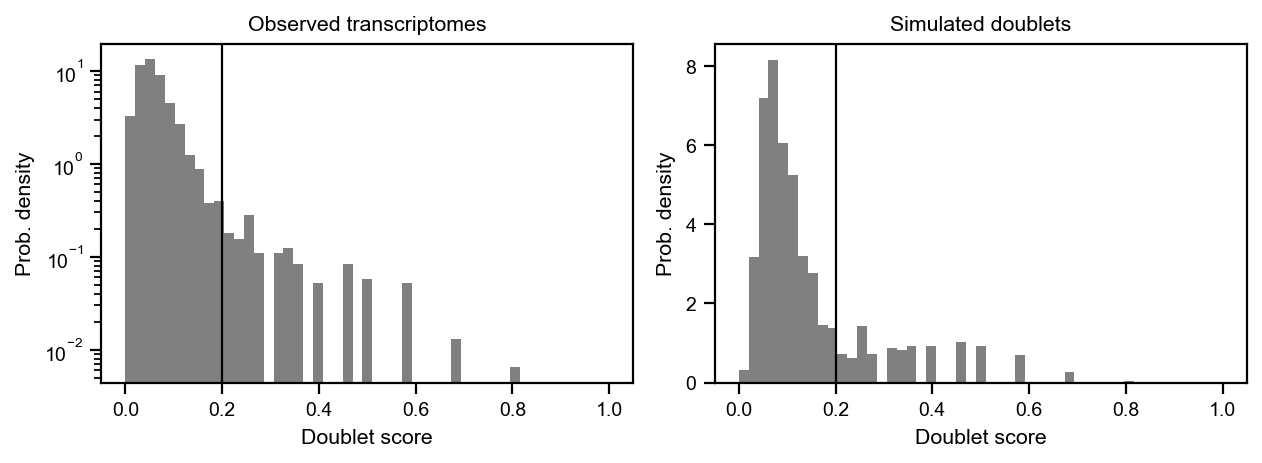

In [11]:
stromal = rna.qc.scrublet(
    stromal,
    doublet_threshold = 0.2,
    raw_counts_layer = "raw_counts",
    subset=False,
)

In [12]:
stromal = stromal[~stromal.obs.scrublet_called_doublet].copy()
stromal

AnnData object with n_obs × n_vars = 7349 × 13383
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'scrublet_batch_key', 'scrublet_score', 'scrublet_called_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.18
Detected doublet rate = 6.6%
Estimated detectable doublet fraction = 39.5%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 16.7%
Elapsed time: 12.8 seconds
Detected doublet rate = 5.2%
Estimated detectable doublet fraction = 32.7%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 15.8%


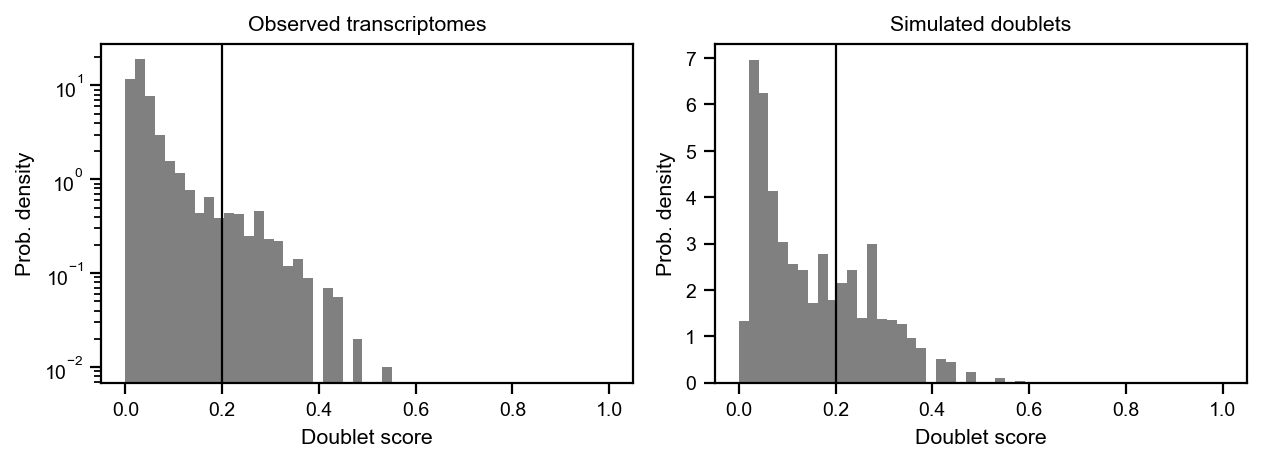

In [13]:
myeloid = rna.qc.scrublet(
    myeloid,
    doublet_threshold = 0.2,
    raw_counts_layer = "raw_counts",
    subset=False,
)

In [14]:
myeloid = myeloid[~myeloid.obs.scrublet_called_doublet].copy()
myeloid

AnnData object with n_obs × n_vars = 14003 × 12866
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'scrublet_batch_key', 'scrublet_score', 'scrublet_called_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

## QC filter

### Stromal

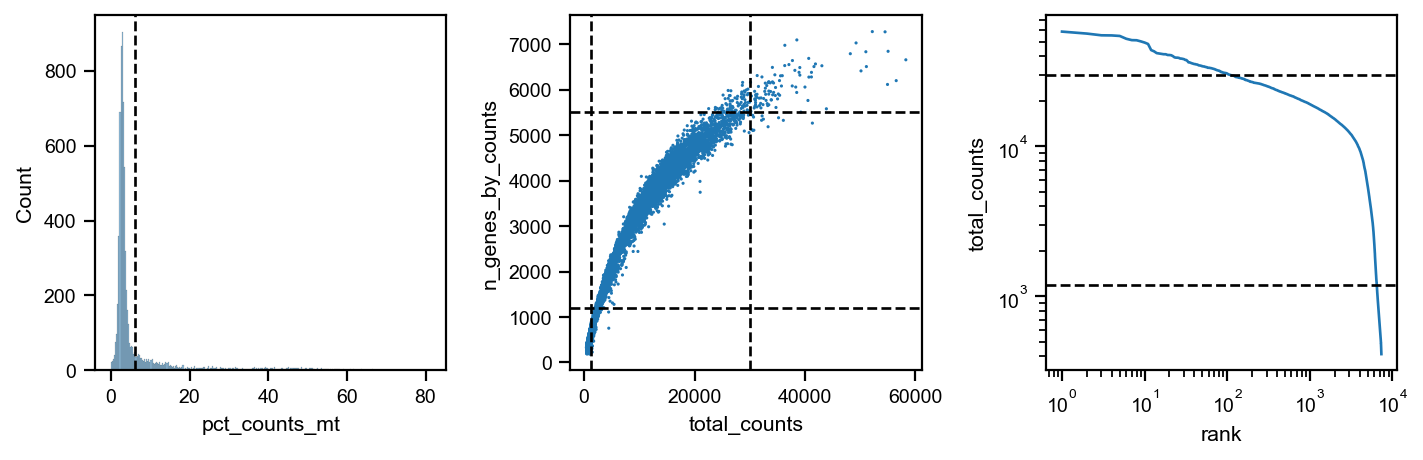

In [15]:
# Set thresholds
countsThreshold = [1200, 30000]
genesThreshold = [1200, 5500]
mtThreshold = 6
# Check QC thresholds before filtering
rna.pl.qc_plotting(
    stromal,
    counts_thresholds=countsThreshold,
    genes_thresholds=genesThreshold,
    mt_threshold=mtThreshold,
)

In [16]:
filtered_stromal = rna.qc.filter_cells(
    stromal,
    counts_thresholds=countsThreshold, 
    genes_thresholds=genesThreshold, 
    mt_threshold=mtThreshold,
)

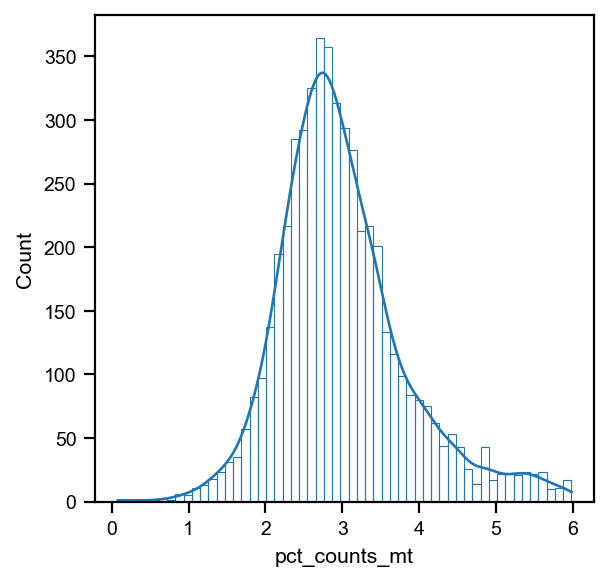

In [17]:
sns.histplot(
    filtered_stromal.obs,
    x="pct_counts_mt",
    kde=True,
    fill=False
)
plt.show()

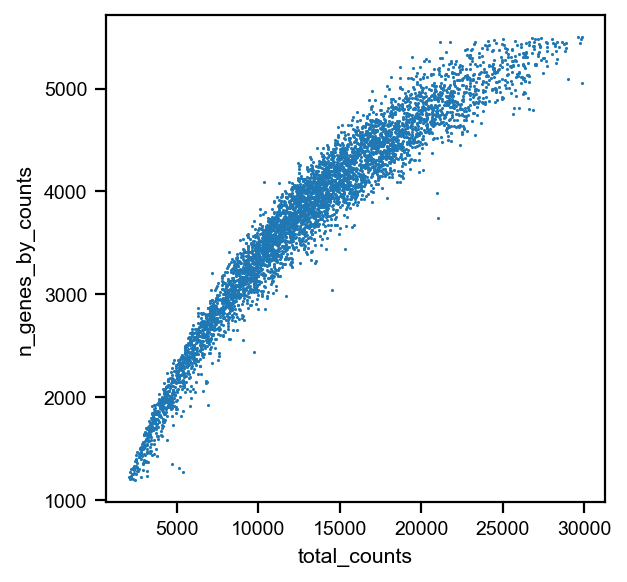

In [18]:
sns.scatterplot(
    filtered_stromal.obs,
    x="total_counts",
    y="n_genes_by_counts",
    s=2,
    linewidth=0
)
plt.show()

In [19]:
# overwrite original adata variable with the filtered data
stromal = filtered_stromal.copy()
del filtered_stromal
stromal

AnnData object with n_obs × n_vars = 5133 × 13383
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'scrublet_batch_key', 'scrublet_score', 'scrublet_called_doublet', 'qc_plot_batch'
    var: 'gene_ids', 'feature_types', 'genome', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

### Myeloid

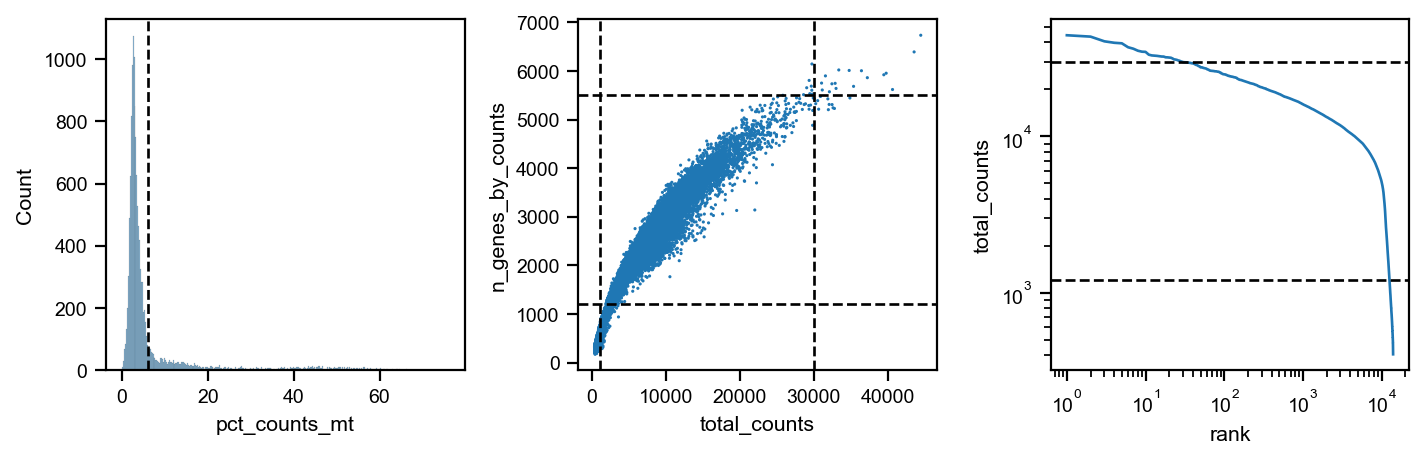

In [20]:
# Set thresholds
countsThreshold = [1200, 30000]
genesThreshold = [1200, 5500]
mtThreshold = 6
# Check QC thresholds before filtering
rna.pl.qc_plotting(
    myeloid,
    counts_thresholds=countsThreshold,
    genes_thresholds=genesThreshold,
    mt_threshold=mtThreshold,
)

In [21]:
filtered_myeloid = rna.qc.filter_cells(
    myeloid,
    counts_thresholds=countsThreshold, 
    genes_thresholds=genesThreshold, 
    mt_threshold=mtThreshold,
)

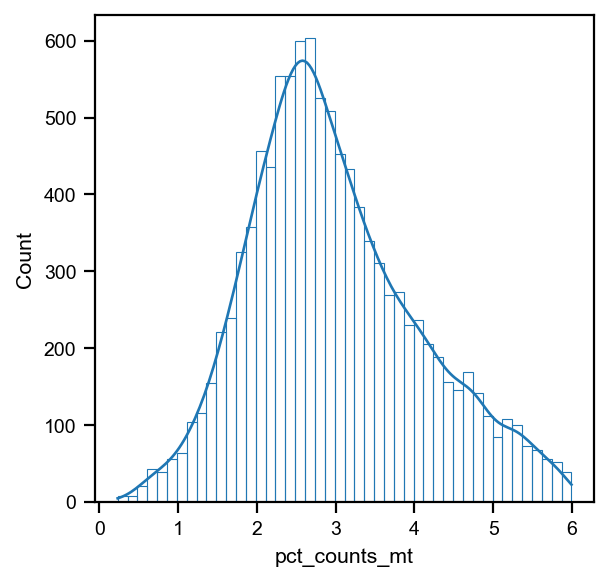

In [22]:
sns.histplot(
    filtered_myeloid.obs,
    x="pct_counts_mt",
    kde=True,
    fill=False
)
plt.show()

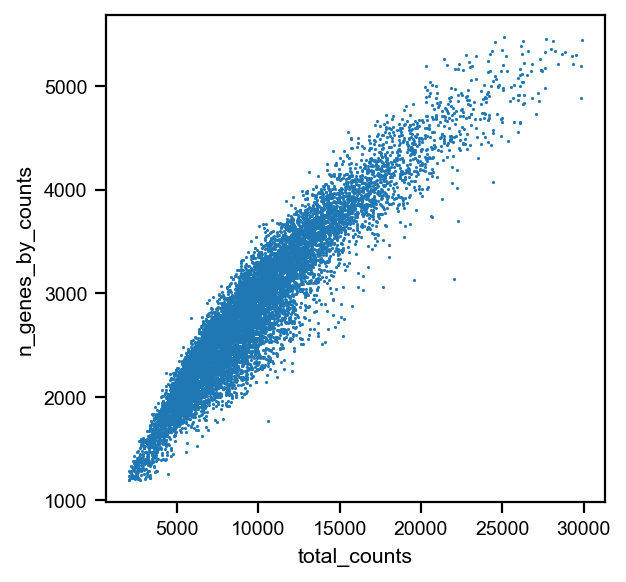

In [23]:
sns.scatterplot(
    filtered_myeloid.obs,
    x="total_counts",
    y="n_genes_by_counts",
    s=2,
    linewidth=0
)
plt.show()

In [24]:
# overwrite original adata variable with the filtered data
myeloid = filtered_myeloid.copy()
del filtered_myeloid
myeloid

AnnData object with n_obs × n_vars = 10609 × 12866
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'scrublet_batch_key', 'scrublet_score', 'scrublet_called_doublet', 'qc_plot_batch'
    var: 'gene_ids', 'feature_types', 'genome', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

## Normalize data (scanpy)

In [25]:
# Scanpy preprocessing pipeline
stromal.raw = stromal
sc.pp.normalize_total(stromal, target_sum=1e4)
sc.pp.log1p(stromal)
stromal.layers["log1p"] = stromal.X.copy()

In [26]:
# Scanpy preprocessing pipeline
myeloid.raw = myeloid
sc.pp.normalize_total(myeloid, target_sum=1e4)
sc.pp.log1p(myeloid)
myeloid.layers["log1p"] = myeloid.X.copy()

# scVI training

## Stromal

In [27]:
# Setup scVI model using raw counts and batch info
scvi.model.SCVI.setup_anndata(
    stromal,
    layer="raw_counts",
)
stromal_model = scvi.model.SCVI(stromal)

In [28]:
# Train scVI model
stromal_model.train(
    early_stopping=True,
    max_epochs=1000,
    accelerator="gpu",
    devices="auto" 
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 9759.585. Signaling Trainer to stop.


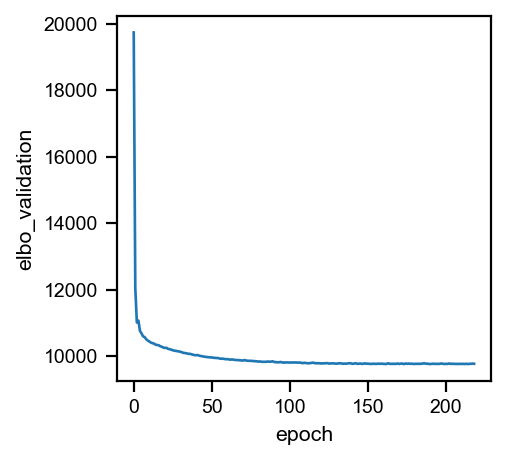

In [29]:
# Plot model ELBO
plt.figure(figsize=(3,3))
ax = sns.lineplot(stromal_model.history['elbo_validation'])
plt.ylabel("elbo_validation")
ax.get_legend().remove()
plt.show()

In [30]:
# get scVI latent space and normalized expression
stromal.obsm["X_scVI"] = stromal_model.get_latent_representation()
stromal.layers["scVI_normalized"] = stromal_model.get_normalized_expression(library_size=1e4)

In [31]:
# Dimensionality reduction
sc.pp.neighbors(stromal, use_rep="X_scVI")
sc.tl.umap(stromal)

... storing 'scrublet_batch_key' as categorical
... storing 'qc_plot_batch' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'gene_biotype' as categorical


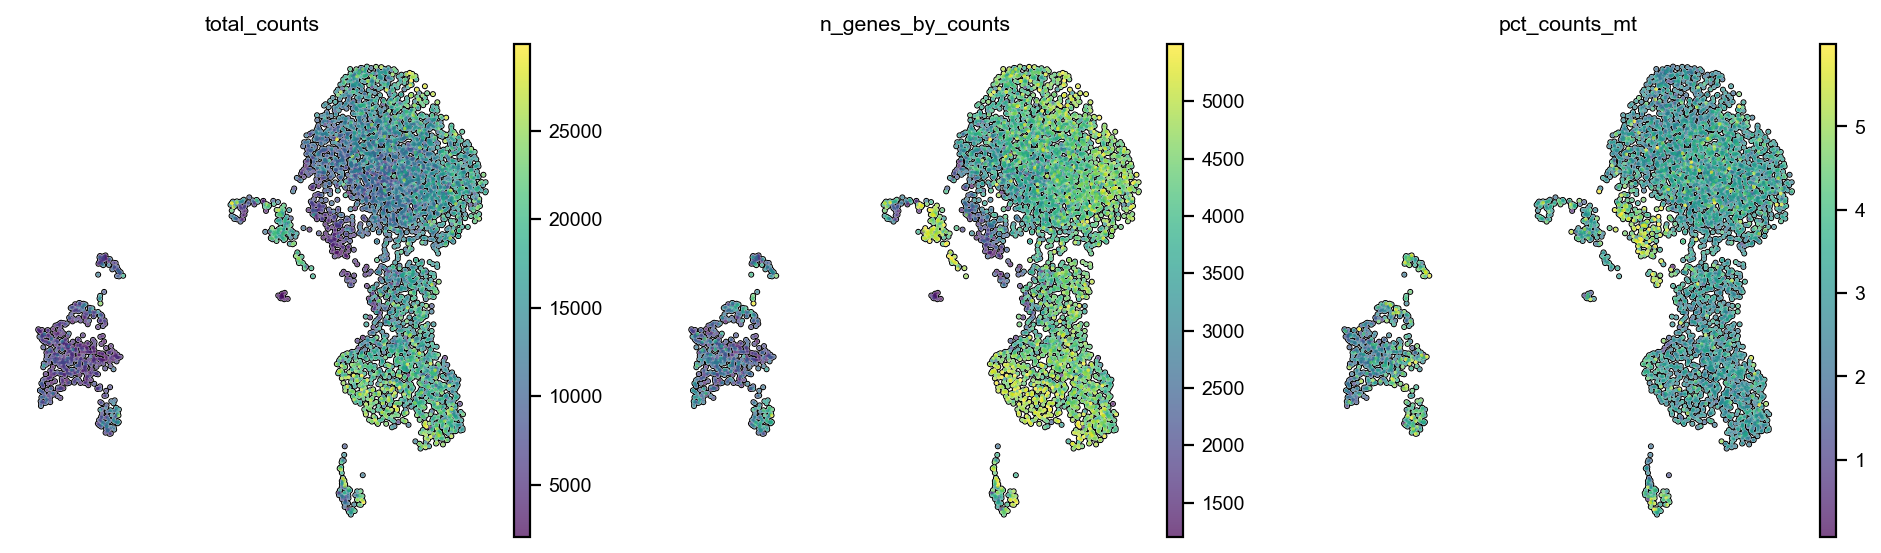

In [32]:
sc.pl.umap(
    stromal,
    color=["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    s=10,
    add_outline=True,
    palette=cmap,
)

## Myeloid

In [33]:
# Setup scVI model using raw counts and batch info
scvi.model.SCVI.setup_anndata(
    myeloid,
    layer="raw_counts",
)
myeloid_model = scvi.model.SCVI(myeloid)

In [34]:
# Train scVI model
myeloid_model.train(
    early_stopping=True,
    max_epochs=1000,
    accelerator="gpu",
    devices="auto" 
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 7607.750. Signaling Trainer to stop.


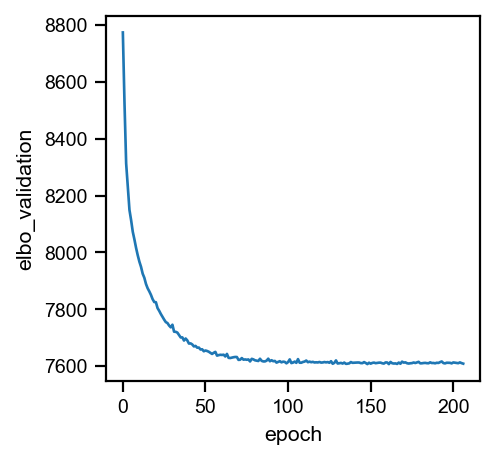

In [35]:
# Plot model ELBO
plt.figure(figsize=(3,3))
ax = sns.lineplot(myeloid_model.history['elbo_validation'])
plt.ylabel("elbo_validation")
ax.get_legend().remove()
plt.show()

In [36]:
# get scVI latent space and normalized expression
myeloid.obsm["X_scVI"] = myeloid_model.get_latent_representation()
myeloid.layers["scVI_normalized"] = myeloid_model.get_normalized_expression(library_size=1e4)

In [37]:
# Dimensionality reduction
sc.pp.neighbors(myeloid, use_rep="X_scVI")
sc.tl.umap(myeloid)

... storing 'scrublet_batch_key' as categorical
... storing 'qc_plot_batch' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'gene_biotype' as categorical


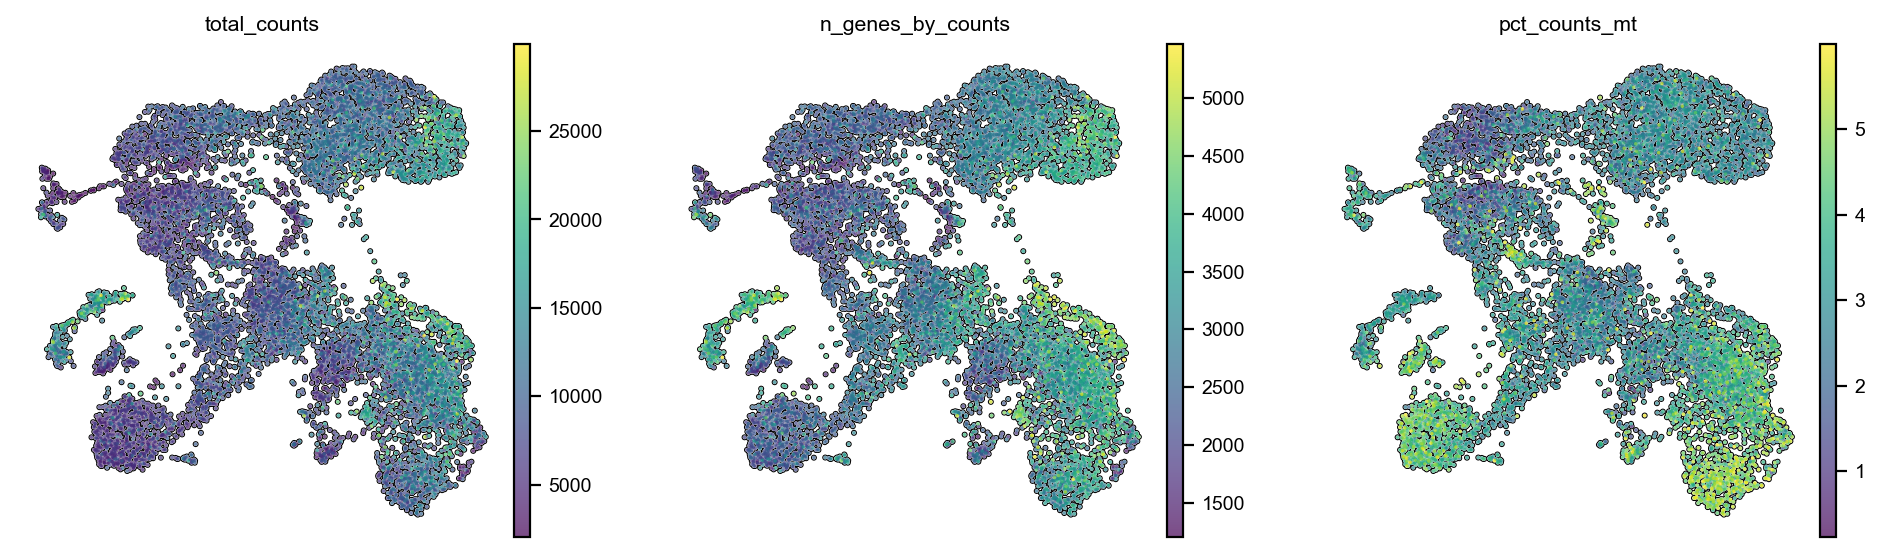

In [38]:
sc.pl.umap(
    myeloid,
    color=["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    s=10,
    add_outline=True,
    palette=cmap,
)

# Clustering

## Stromal

In [60]:
sc.tl.leiden(stromal, key_added="leiden_scVI", resolution=0.30)

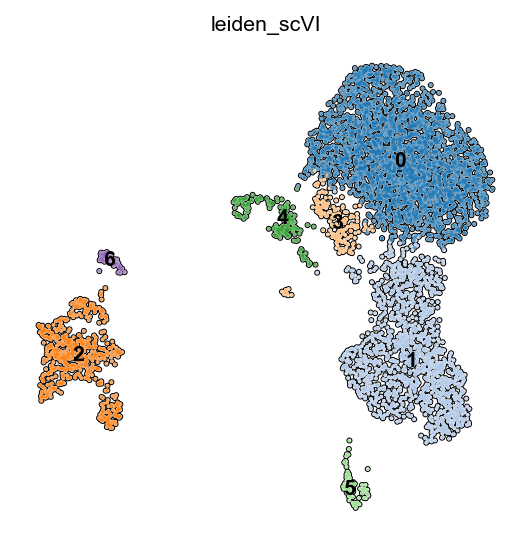

In [61]:
sc.pl.umap(
    stromal,
    color=["leiden_scVI"],
    legend_loc="on data",
    palette=new_tab20,
    s=10,
    add_outline=True,
)

## Myeloid

In [46]:
sc.tl.leiden(myeloid, key_added="leiden_scVI", resolution=0.5)

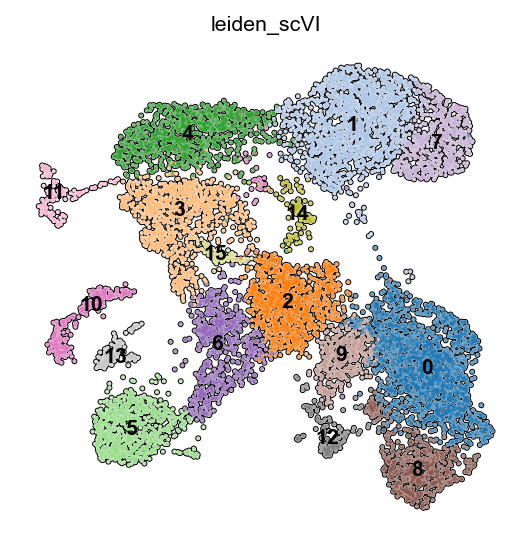

In [47]:
sc.pl.umap(
    myeloid,
    color=["leiden_scVI"],
    legend_loc="on data",
    palette=new_tab20,
    s=10,
    add_outline=True,
)

# Save data

In [62]:
# Check save paths
if not os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models"):
    os.makedirs(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models")
    
if not os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files"):
    os.makedirs(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files")
    
if os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/stromal"):
    shutil.rmtree(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/stromal")

if os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/myeloid"):
    shutil.rmtree(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/myeloid")

stromal_model.save(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/stromal")
myeloid_model.save(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/myeloid")
stromal.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/stromal.h5ad")
myeloid.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/myeloid.h5ad")